# Capstone Three: Online Shopper Purchase Intent

## Data Wrangling and Exploratory Data Analysis

### Capstone Objective

The objective of this capstone project is to develop a deep learning model that predicts whether an online shopping session will result in a purchase. The model is intended to support e-commerce conversion optimization by identifying visitors with higher purchase intent based on their browsing behavior and session characteristics.

This notebook focuses on data loading, data quality assessment, exploratory analysis, and preparation of the dataset for modeling.

### Variable Descriptions

The Online Shoppers Purchasing Intention dataset contains 17 predictor variables and one binary target variable (`Revenue`). The variables describe visitor browsing behavior, session characteristics, and visitor attributes.

#### A. Browsing Behavior

These variables capture how visitors interact with different types of pages during their shopping session. The values are derived from the URLs visited
during the session and are updated as the visitor takes actions, such as moving from one page to another.

| Variable | Description |
|---|---|
| `Administrative` | Number of administrative pages visited during the session. |
| `Administrative_Duration` | Total time spent on administrative pages during the session. |
| `Informational` | Number of informational pages visited during the session. |
| `Informational_Duration` | Total time spent on informational pages during the session. |
| `ProductRelated` | Number of product-related pages visited during the session. |
| `ProductRelated_Duration` | Total time spent on product-related pages during the session. |

#### B. Website Engagement & Page-Level Metrics

These variables represent metrics measured by Google Analytics for pages visited during the shopping session.

| Variable | Description |
|---|---|
| `BounceRates` | The percentage of visitors who enter the site through a page and leave without triggering another request to the analytics server during that session. |
| `ExitRates` | For a specific page, the percentage of pageviews for which that page was the final pageview in the session. |
| `PageValues` | The average value of the pages visited by a user before completing an e-commerce transaction. |

These metrics provide additional information about visitor engagement and the relationship between pages viewed and eventual transaction activity. Because `PageValues` is defined in relation to pages visited before an e-commerce transaction, its timing and potential for temporal leakage will be considered during feature selection.

#### C. Timing & Seasonal Characteristics

| Variable | Description |
|---|---|
| `Month` | Month in which the shopping session occurred. |
| `SpecialDay` | A measure of how close the visit occurred to a special shopping day, such as Valentine's Day or Mother's Day, when sessions may be more likely to result in a transaction. |
| `Weekend` | Boolean indicator of whether the shopping session occurred on a weekend. |

`SpecialDay` ranges from 0 to 1, with higher values indicating that the visit occurred closer to the relevant special day.

#### D. Visitor & Technical Characteristics

These variables describe characteristics of the visitor, their browsing environment, and how they arrived at the website.

| Variable | Description |
|---|---|
| `VisitorType` | Visitor classification indicating whether the visitor was a new visitor, returning visitor, or other. |
| `OperatingSystems` | Operating system used by the visitor. |
| `Browser` | Browser used by the visitor. |
| `Region` | Geographic region associated with the visitor. |
| `TrafficType` | Traffic source/type through which the visitor arrived at the website. |

The variables `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are represented as numerical codes in the dataset but represent categorical characteristics rather than continuous numerical measurements.

#### E. Target Variable

| Variable | Description |
|---|---|
| `Revenue` | Boolean target variable indicating whether the shopping session resulted in a purchase (`True`) or did not result in a purchase (`False`). |

The `Revenue` variable will be used as the target for the binary classification models and will not be included as a predictor.

### Import Libraries

In [1]:
# Import libraries 
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

#Install kagglehub
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version of the data
path = kagglehub.dataset_download("henrysue/online-shoppers-intention")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abhi\.cache\kagglehub\datasets\henrysue\online-shoppers-intention\versions\1


In [5]:
import os

os.listdir(path)

['online_shoppers_intention.csv']

### Load Dataset

In [7]:
df = pd.read_csv(os.path.join(path, "online_shoppers_intention.csv"))

### Initial Data Inspection

In [9]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [11]:
#Shape of the data 
df.shape

(12330, 18)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


### Data Quality Assessment

In [17]:
# Check for missing values
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

##### Note on Missing Values

The dataset contains no missing values across any of the 18 variables. Therefore, no missing-value imputation or row removal is required during data preparation.

In [19]:
# Check for duplicate rows
df.duplicated().sum()

125

##### Note on Duplicate Observations

The dataset contains 125 completely duplicated rows, representing approximately 1% of all observations. Because the data represent individual shopping sessions, identical feature combinations may represent legitimate separate sessions rather than data-entry errors. These observations will therefore be retained initially and their impact on model performance can be assessed during model development.

In [21]:
# Unique values for categorical and boolean variables
for col in ["Month", "VisitorType", "Weekend", "Revenue"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


Month:
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

VisitorType:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

Weekend:
Weekend
False    9462
True     2868
Name: count, dtype: int64

Revenue:
Revenue
False    10422
True      1908
Name: count, dtype: int64


##### Observations on Unique values 

1. November has the highest number of observed visits, while February is the least. Missing data for January and April. 
2. Returning visitors have the highest number of visits
3. More visits during non-weekend days. 

In [29]:
for col in ["OperatingSystems", "Browser", "Region", "TrafficType"]:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


OperatingSystems:
OperatingSystems
1    2585
2    6601
3    2555
4     478
5       6
6      19
7       7
8      79
Name: count, dtype: int64

Browser:
Browser
1     2462
2     7961
3      105
4      736
5      467
6      174
7       49
8      135
9        1
10     163
11       6
12      10
13      61
Name: count, dtype: int64

Region:
Region
1    4780
2    1136
3    2403
4    1182
5     318
6     805
7     761
8     434
9     511
Name: count, dtype: int64

TrafficType:
TrafficType
1     2451
2     3913
3     2052
4     1069
5      260
6      444
7       40
8      343
9       42
10     450
11     247
12       1
13     738
14      13
15      38
16       3
17       1
18      10
19      17
20     198
Name: count, dtype: int64


### Exploratory Data Analysis (EDA)

The exploratory data analysis examines the distribution of the target variable and explores relationships between visitor characteristics, browsing behavior, website engagement metrics, and purchase outcomes. The goal is to identify patterns in the data that may inform feature preparation and model development.

In [23]:
# Summary of target variable 
revenue_summary = pd.DataFrame({
    "Count": df["Revenue"].value_counts(),
    "Percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,Count,Percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


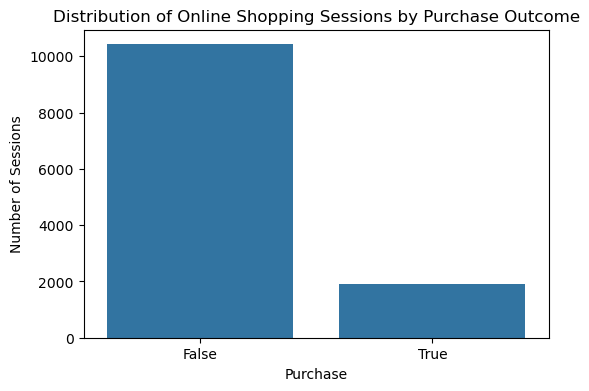

In [25]:
# Visualize the target variable 
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Revenue")

plt.title("Distribution of Online Shopping Sessions by Purchase Outcome")
plt.xlabel("Purchase")
plt.ylabel("Number of Sessions")

plt.show()

##### Observation on Target Variable 

Revenue is imbalanced as only 15.5% of browsing ends in a successful purchase. 

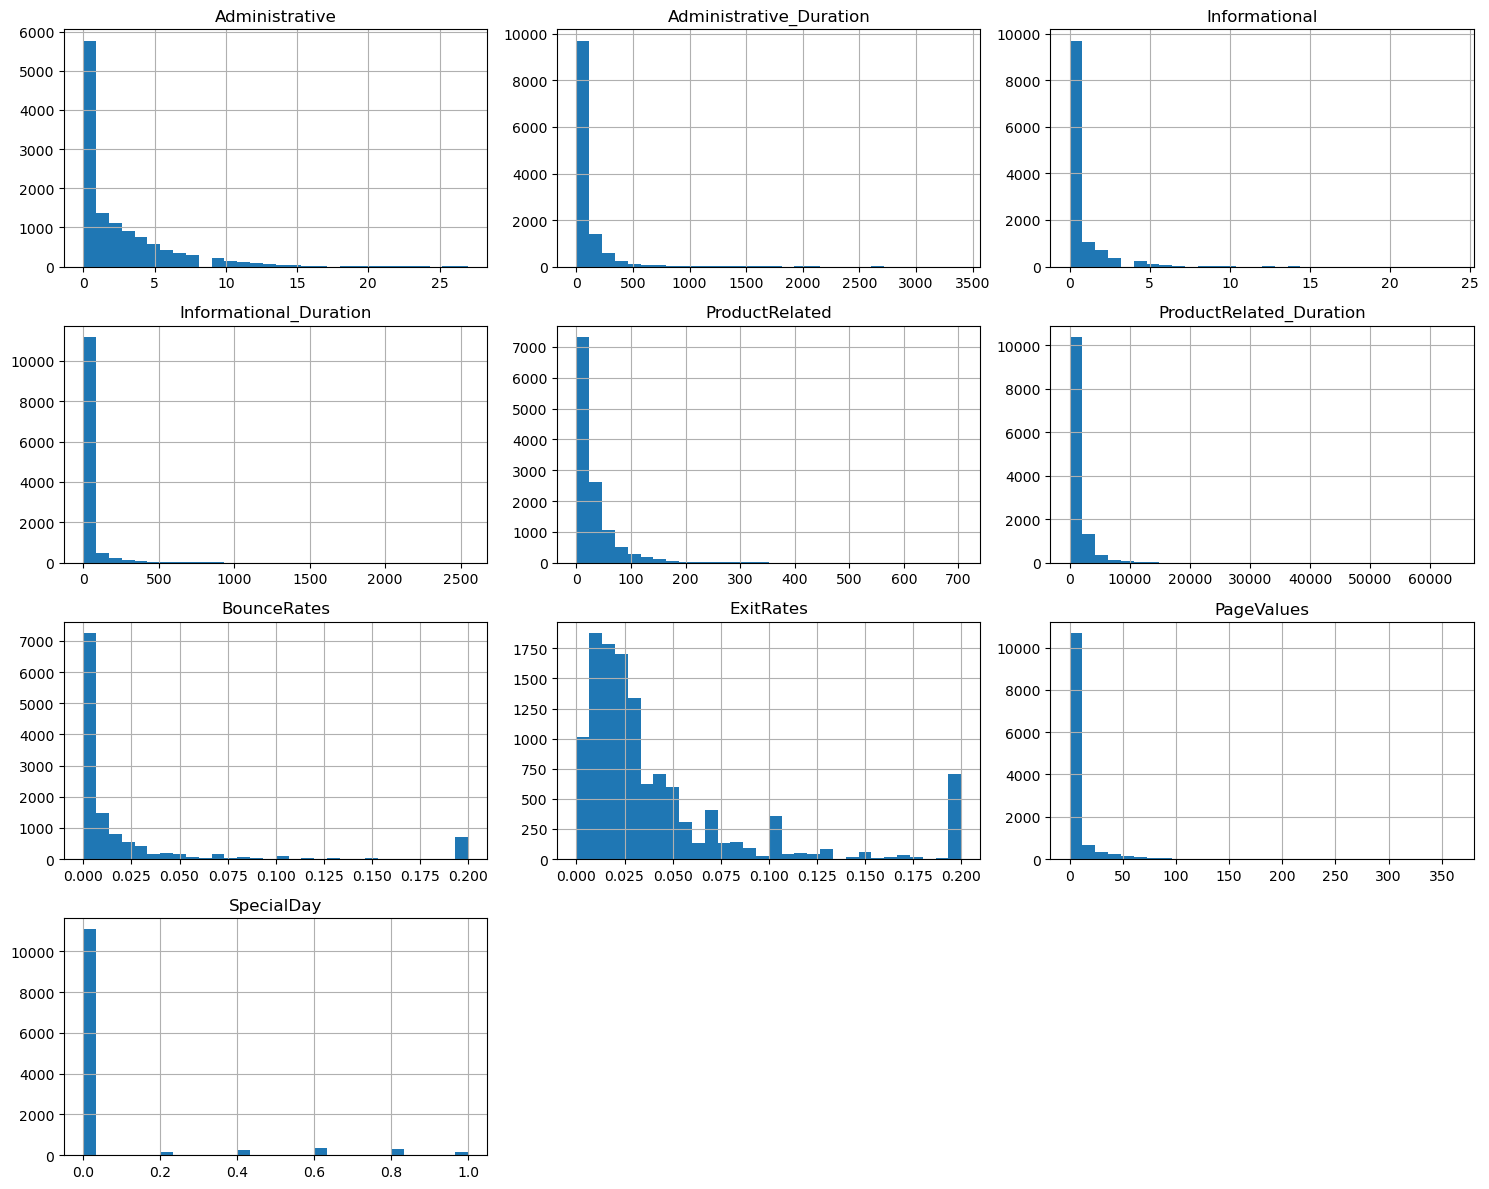

In [29]:
# Check the distribution of all the numerical variables 
numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [31]:
# Check the skewness of the distributions 
df[numeric_cols].skew().sort_values(ascending=False)

Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
BounceRates                2.947855
ExitRates                  2.148789
Administrative             1.960357
dtype: float64

##### Observations

1. The numerical variables are heavily right-skewed, particularly the `Informational_Duration`, `ProductRelated_Duration`, and `PageValues`.

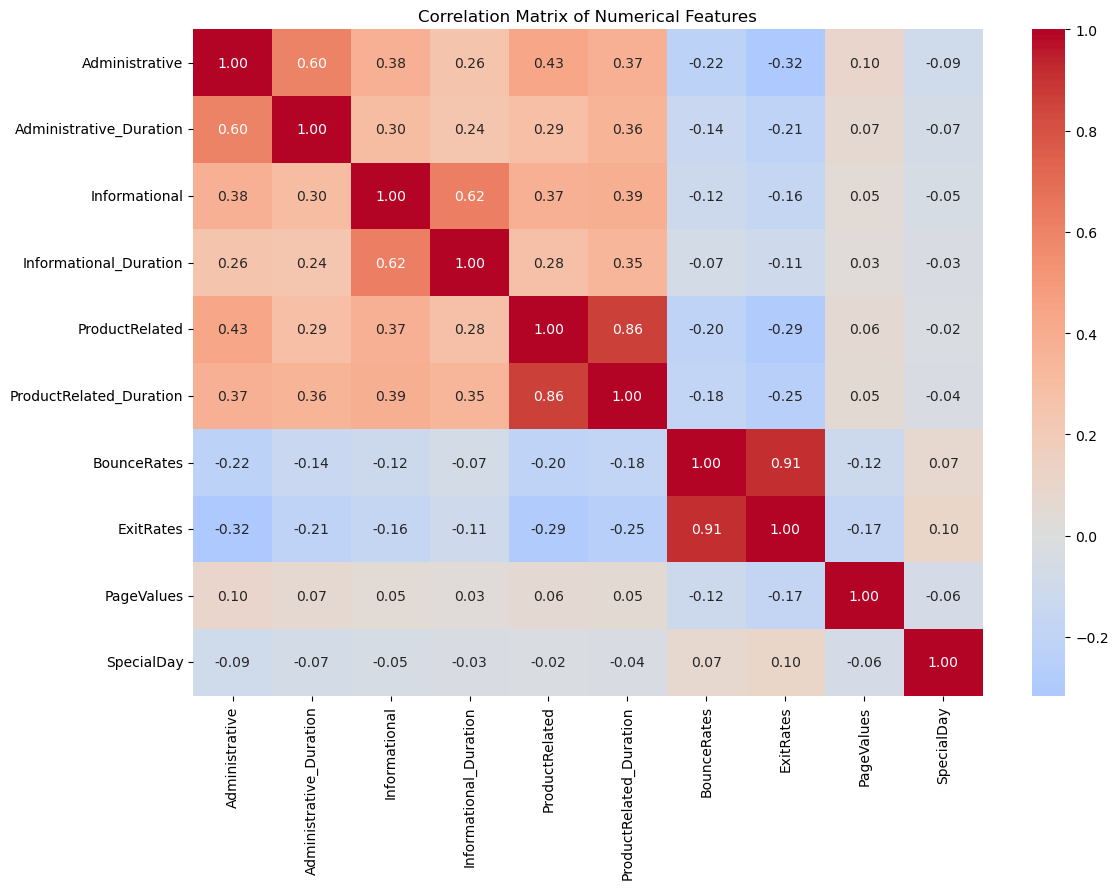

In [35]:
# Check correlation for numerical features
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

##### Observations from the Correlation Matrix

1. A very strong positive correlation was observed between `BounceRates` and `ExitRates` (r = 0.91), suggesting that sessions with higher bounce rates also tend to have higher exit rates.

2. `ProductRelated` and `ProductRelated_Duration` also have a strong positive correlation (r = 0.86), indicating that sessions with more product-related page visits generally involve more time spent on product-related pages.

3. Moderate positive correlations were observed between `Administrative` and `Administrative_Duration` (r = 0.60) and between `Informational` and `Informational_Duration` (r = 0.62).

4. Moderate positive correlations were also observed between `Administrative` and `ProductRelated` (r = 0.43), `Informational` and `ProductRelated` (r = 0.37), and `Informational_Duration` and `ProductRelated_Duration` (r = 0.35).

5. `PageValues` has relatively low correlations with the other numerical features, suggesting that it captures information that is relatively distinct from the other measures of browsing behavior and engagement.

6. `ExitRates` has small to moderate negative correlations with `Administrative` (r = -0.32), `ProductRelated` (r = -0.29), and `ProductRelated_Duration` (r = -0.25). This suggests that sessions with greater website engagement tend to have lower exit rates.

7. The strong correlations between several page-count and duration variables suggest some degree of feature redundancy. However, correlated features will not be removed solely on the basis of pairwise correlation and will be evaluated during model development.

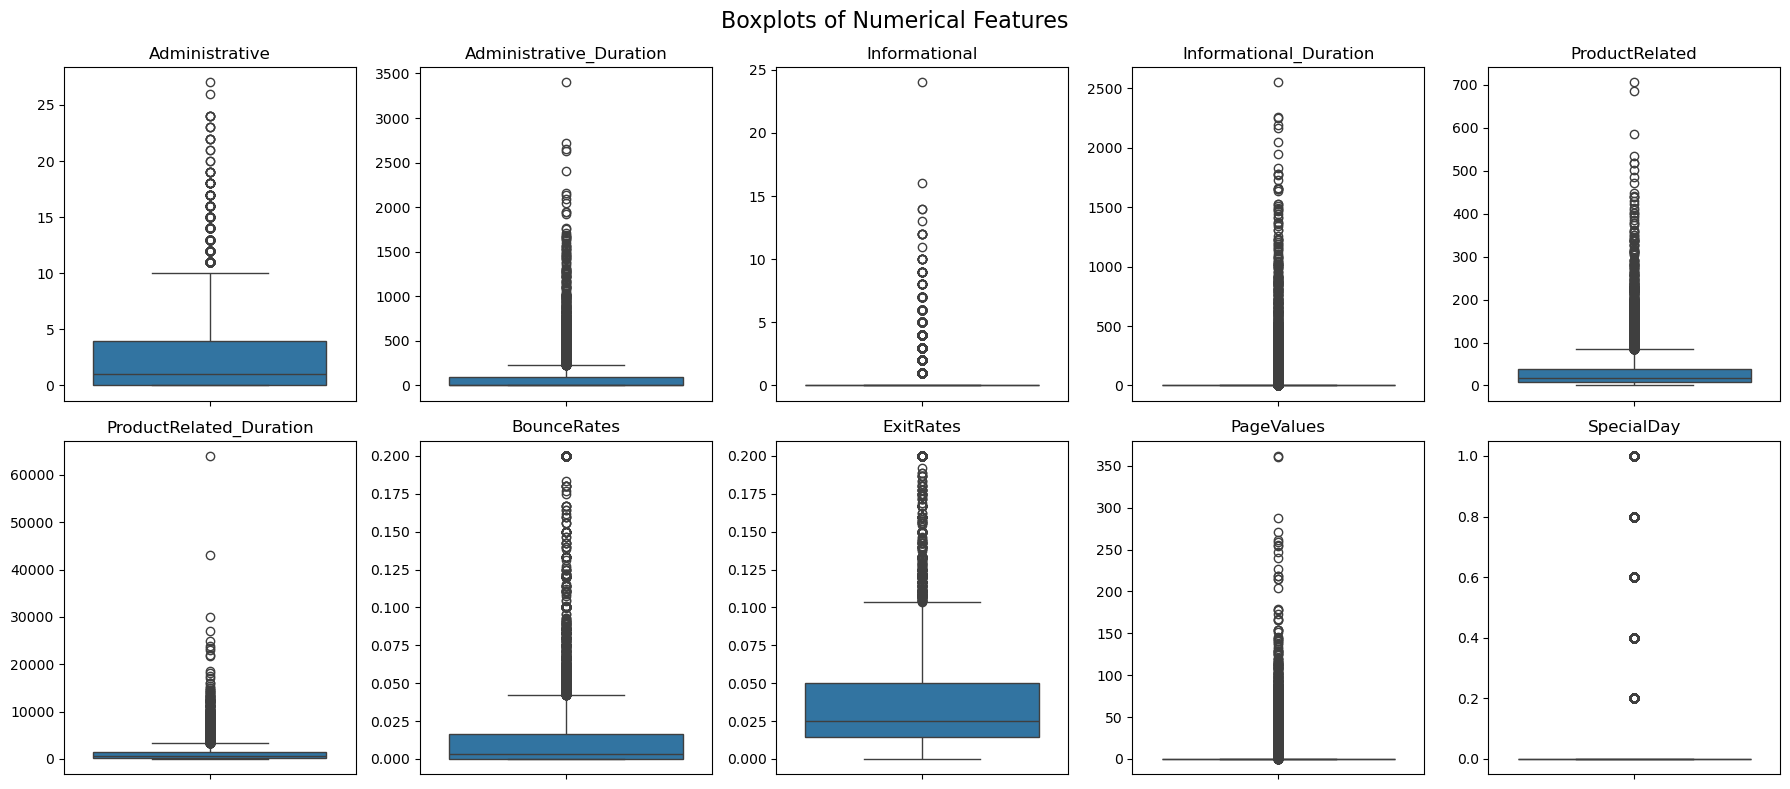

In [50]:
# Check for outliers with box-plots
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")

plt.suptitle("Boxplots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [54]:
# Generate an outlier summary table that calculates % of outliers that fall outside the IQR range for each numerical feature 
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers,
        "Outlier %": (outliers / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values("Outlier %", ascending=False)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier %
8,PageValues,0.000000,0.000000,2730,22.141119
2,Informational,0.000000,0.000000,2631,21.338200
3,Informational_Duration,0.000000,0.000000,2405,19.505272
6,BounceRates,-0.025219,0.042031,1551,12.579075
9,SpecialDay,0.000000,0.000000,1251,10.145985
1,Administrative_Duration,-139.884375,233.140625,1172,9.505272
7,ExitRates,-0.039286,0.103571,1099,8.913220
4,ProductRelated,-39.500000,84.500000,987,8.004866
5,ProductRelated_Duration,-1735.892070,3384.186784,961,7.793998
0,Administrative,-6.000000,10.000000,404,3.276561


##### Observations

1. Several numerical variables contain observations outside the 1.5 × IQR thresholds. The largest proportions occur for `PageValues` (22.1%), `Informational` (21.3%), and `Informational_Duration` (19.5%).

2. The IQR method identifies a large number of observations as statistical outliers for `PageValues`, `Informational`, `Informational_Duration`, and `SpecialDay` because these variables are highly zero-inflated. For these variables, the first and third quartiles are both equal to zero, causing
every nonzero observation to fall outside the IQR-based upper bound.

4. The remaining numerical variables also contain observations in the upper tails of their distributions, particularly `BounceRates`, `Administrative_Duration`, `ExitRates`, `ProductRelated`, and `ProductRelated_Duration`. These observations are consistent with the heavily right-skewed distributions identified earlier.

5. Because the extreme values may represent legitimate differences in visitor engagement rather than data-quality errors, observations will not be removed solely on the basis of the IQR method. The full dataset will be retained for subsequent modeling, with numerical features appropriately scaled during preprocessing.

In [47]:
# Explore feature-target relationships 

# Purchase rate by visitor type
df.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False)

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

In [50]:
# Purchase rate by month
df.groupby("Month")["Revenue"].mean().sort_values(ascending=False)

Month
Nov     0.253502
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.125072
May     0.108502
June    0.100694
Mar     0.100682
Feb     0.016304
Name: Revenue, dtype: float64

In [52]:
# Purchase rate by weekday/weekend
df.groupby("Weekend")["Revenue"].mean()

Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64

In [54]:
# Purchase rate across different features
df.groupby("Revenue")[numeric_cols].median().T

Revenue,False,True
Administrative,0.000000,2.000000
Administrative_Duration,0.000000,52.366667
Informational,0.000000,0.000000
Informational_Duration,0.000000,0.000000
ProductRelated,16.000000,29.000000
ProductRelated_Duration,510.190000,1109.906250
BounceRates,0.004255,0.000000
ExitRates,0.028571,0.016000
PageValues,0.000000,16.758134
SpecialDay,0.000000,0.000000


##### Observations

1. New visitors had the highest observed purchase rate in the dataset (24.9%), compared with 13.9% among returning visitors.
2. November had the highest observed purchase rate (25.4%), while February had the lowest (1.6%).
3. Sessions occurring on weekends had a slightly higher observed purchase rate (17.4%) compared with sessions occurring on weekdays (14.9%).
4. Purchasing sessions had a higher median number of product-related page visits (29) compared with non-purchasing sessions (16) and spent more than twice as much time on product-related pages (1,109.9 seconds vs. 510.2 seconds).
5. Purchasing sessions had higher median administrative page visits (2) and administrative page duration (52.4 seconds) compared with non-purchasing sessions, which had medians of 0 for both measures.
6. Purchasing sessions had lower median bounce rates (0.00 vs. 0.0043) and exit rates (0.016 vs. 0.0286) compared with non-purchasing sessions.

## Next Steps

Based on the findings from the exploratory analysis, the next stage will focus on preparing the dataset for machine learning.

The following steps will be completed:

1. Define the final predictor and target variables, including evaluating whether `PageValues` and other session-level metrics are appropriate for the
 intended prediction use case.

2. Separate numerical, categorical, and Boolean features so that each group can receive appropriate preprocessing.

3. Split the data into training, validation, and test sets while preserving the distribution of the target variable.

4. Develop a reproducible preprocessing pipeline that encodes categorical variables and scales numerical features. Preprocessing parameters will be learned using the training data only to prevent data leakage.

5. Establish a traditional machine learning baseline for comparison with the deep neural network.

6. Develop and evaluate a feedforward neural network for predicting online purchase intent, with particular attention to performance metrics that account for the imbalanced target variable.

7. Save the final model and preprocessing pipeline in a format that can be used for deployment on Paperspace.